In [1]:
import numpy as np
from scipy.ndimage import laplace, sobel, gaussian_filter, uniform_filter
from matplotlib import rc
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import ListedColormap
rc("font", family="serif")
rc("pgf", texsystem="pdflatex")
rc("text", usetex=True)
# rc('text.latex', unicode=True)
rc("text.latex", preamble=r"\usepackage{amssymb}")
rc("text.latex", preamble=r"\usepackage[T1,T2A]{fontenc}")
rc("text.latex", preamble=r"\usepackage[utf8]{inputenc}")
rc("text.latex", preamble=r"\usepackage[english,russian]{babel}")
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.colors import ListedColormap
from mex_4_5.config import setup_model_and_geometry
from mex_4_5.config import PATH_DATA_DSUB, TMAX, OUTPUT_DIRS, NBL

In [2]:
model, dataset, velmodel = setup_model_and_geometry(path_data=PATH_DATA_DSUB)
dataset._dt_r = model.critical_dt
dataset._t_max_r = TMAX
dataset.resample_on()

Operator `initdamp` ran in 0.01 s


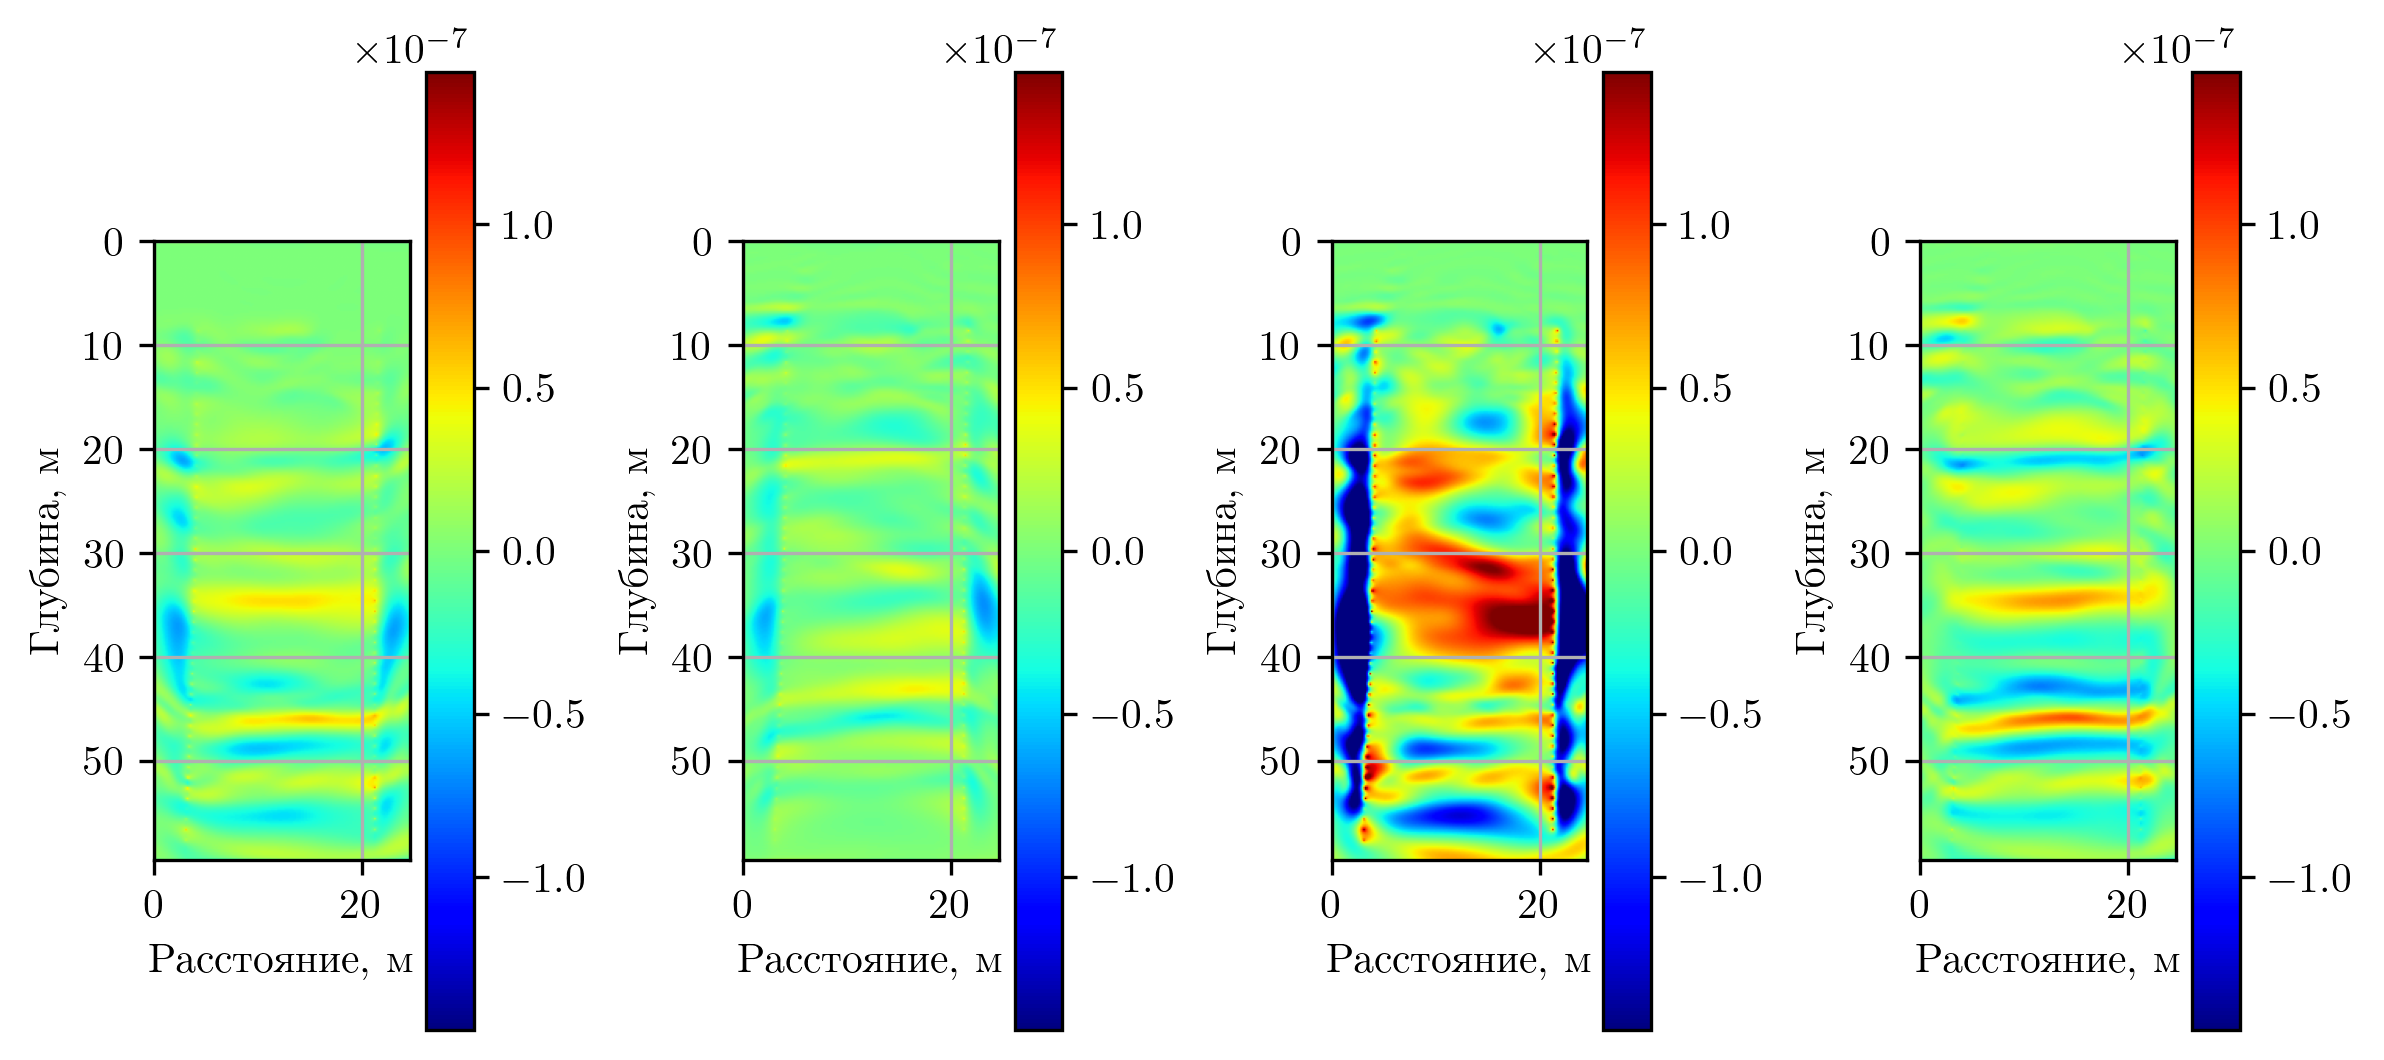

In [3]:
grad_u0 = np.load(f"{OUTPUT_DIRS['gradients']}/grad_full_u_0.npy")
grad_d0 = np.load(f"{OUTPUT_DIRS['gradients']}/grad_full_d_0.npy")
grad_c0 = np.load(f"{OUTPUT_DIRS['gradients']}/grad_full_c_0.npy")


fig, axs = plt.subplots(1, 4, figsize=(8, 4), dpi=300)
glmax = max([np.quantile(grad_d0, 0.99), np.quantile(grad_u0, 0.99), np.quantile(grad_c0, 0.99)])
imag0 = -grad_u0+grad_d0
for gr, ax in zip([grad_d0, grad_u0, grad_c0, imag0], axs):
    h=ax.imshow(gr.T, vmin=-glmax, vmax=glmax, cmap='jet', extent=[0, grad_d0.shape[0]*0.03*5, grad_d0.shape[1]*0.03*5, 0])
    # hh=ax.imshow(model.vp.data[NBL:-NBL, NBL:-NBL].T, cmap='jet', vmin=0.5, vmax=5.5, alpha=0.99, extent=[0, grad_d0.shape[0]*0.03*5, grad_d0.shape[1]*0.03*5, 0])
    ax.set_xlabel("Расстояние, м")
    ax.set_ylabel("Глубина, м")
    ax.grid()
    fig.colorbar(h)



plt.tight_layout()
plt.show()

In [4]:
from scipy import stats
def process_model(velmodel, dataset, grads, invert_wells=False, scalar=1, apply_func=lambda x: laplace(x)):
    grad_u0, grad_d0, grad_c0 = grads
    extent = [velmodel.x[0], velmodel.x[-1], velmodel.z[-1], velmodel.z[0]]

    if invert_wells:
        slope2, intercept2, _, _, _ = stats.linregress(dataset.x_coords, dataset.elevations)
        slope1, intercept1, _, _, _ = stats.linregress(dataset.opposite_x, dataset.opposite_elev)
    else:
        slope1, intercept1, _, _, _ = stats.linregress(dataset.x_coords, dataset.elevations)
        slope2, intercept2, _, _, _ = stats.linregress(dataset.opposite_x, dataset.opposite_elev)        

    # Create meshgrid for masking
    x = np.linspace(extent[0], extent[1], grad_u0.shape[0])
    z = np.linspace(extent[3], extent[2], grad_u0.shape[1])
    xx, zz = np.meshgrid(x, z, indexing='ij')

    # Create masks
    # For well1 (left boundary): points should be to the right of well1
    mask1 = xx > (zz - intercept1)/slope1 if slope1 != 0 else xx > intercept1
    # For well2 (right boundary): points should be to the left of well2
    mask2 = xx < (zz - intercept2)/slope2 if slope2 != 0 else xx < intercept2
    # Combined mask (between wells)
    between_wells_mask = mask1 & mask2

    # Apply masks to gradients and image
    grad_d0_masked = apply_func(grad_d0) * between_wells_mask
    grad_u0_masked = apply_func(grad_u0) * between_wells_mask
    grad_c0_masked = apply_func(grad_c0) * between_wells_mask
    imag0_masked = apply_func(-grad_u0 + grad_d0) * between_wells_mask

    # grad_d0_masked[grad_d0_masked==0] = np.nan
    # grad_u0_masked[grad_u0_masked==0] = np.nan
    # imag0_masked[imag0_masked==0] = np.nan

    return grad_d0_masked*scalar, grad_u0_masked*scalar, imag0_masked*scalar, grad_c0_masked*scalar

grads2 = process_model(velmodel=velmodel, dataset=dataset, grads=[grad_u0, grad_d0, grad_c0], invert_wells=False, apply_func=lambda x: laplace(gaussian_filter(x, sigma=0.9)))
grad_d1, grad_u1, imag1, grad_c1 = grads2

In [5]:
all_grad_u0 = np.load(f"{OUTPUT_DIRS['gradients']}/all_grad_u_0.npy")
all_grad_d0 = np.load(f"{OUTPUT_DIRS['gradients']}/all_grad_d_0.npy")
all_grad_c0 = np.load(f"{OUTPUT_DIRS['gradients']}/all_grad_c_0.npy")

for i in range(all_grad_u0.shape[0]):
    all_grad_u0[i] /= np.linalg.norm(all_grad_u0[i])
    all_grad_d0[i] /= np.linalg.norm(all_grad_d0[i])
    all_grad_c0[i] /= np.linalg.norm(all_grad_c0[i])


grad_u0 = np.mean(all_grad_u0, axis=0)
grad_d0 = np.mean(all_grad_d0, axis=0)
grad_c0 = np.mean(all_grad_c0, axis=0)

grads2 = process_model(velmodel=velmodel, dataset=dataset, grads=[grad_u0, grad_d0, grad_c0], invert_wells=False, apply_func=lambda x: laplace(gaussian_filter(x, sigma=0.7)))
grad_d1, grad_u1, imag1, grad_c1 = grads2

In [6]:
print(model.vp.data[NBL:-NBL+1, NBL:-NBL+1][::5, ::5].shape)
print(grad_d1.shape)

(164, 397)
(164, 397)


In [9]:
grad_c0.shape

(164, 397)

In [ ]:
from examples.seismic.rtm_core.utils import upsample_image

grad_ups = upsample_image()

fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=300)
imag0 = grad_u0-grad_d0
buff = np.array(model.vp.data[NBL:-NBL+1, NBL:-NBL+1][::5, ::5])
buff1 = buff + grad_c0/np.max(np.abs(grad_c0))*0.1*(5.5-0.5)

buff = np.array(model.vp.data[NBL:-NBL, NBL:-NBL])
buff2 = buff + grad_ups/np.max(np.abs(grad_ups))*0.1*(5.5-0.5)

for gr, ax in zip([grad_d0, grad_u0, grad_c0, imag0], axs):
    # h=ax.imshow(gr.T, vmin=-glmax, vmax=glmax, cmap='jet', extent=[0, grad_d0.shape[0]*0.03*5, grad_d0.shape[1]*0.03*5, 0])
    hh=ax.imshow(buff1.T, cmap='jet', vmin=0.5, vmax=5.5, alpha=0.99, extent=[0, grad_d0.shape[0]*0.03*5, grad_d0.shape[1]*0.03*5, 0])
    ax.set_xlabel("Расстояние, м")
    ax.set_ylabel("Глубина, м")
    ax.grid()
    # fig.colorbar(h)



plt.tight_layout()
plt.show()

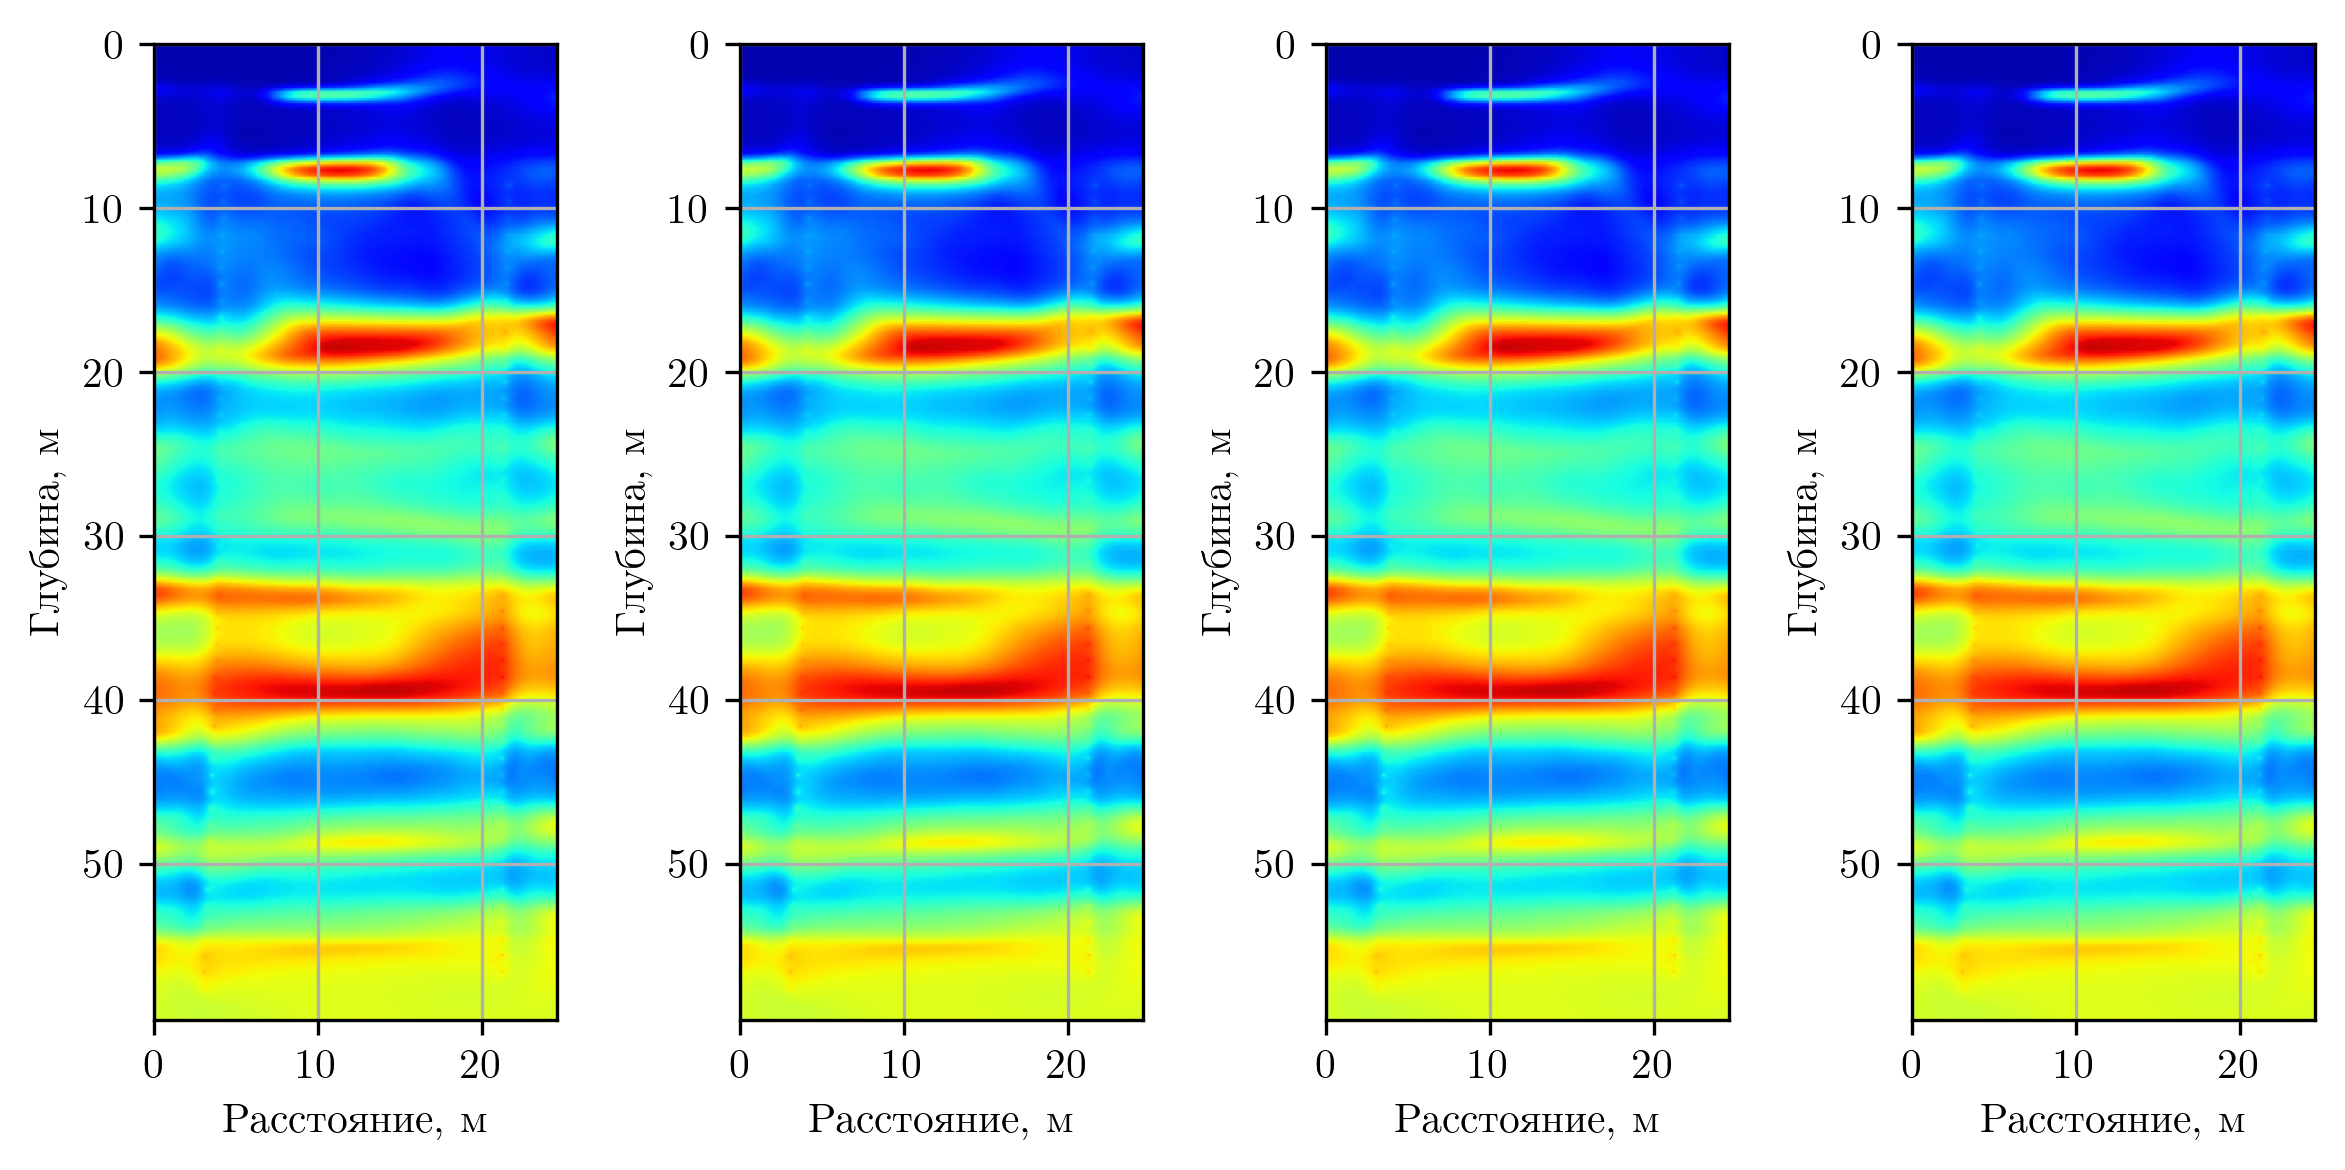

In [8]:
fig, axs = plt.subplots(1, 4, figsize=(8, 4), dpi=300)
glmax = max([np.quantile(grad_d0, 0.99), np.quantile(grad_u0, 0.99), np.quantile(grad_c0, 0.99)])
imag0 = grad_u0-grad_d0
buff = np.array(model.vp.data[NBL:-NBL+1, NBL:-NBL+1][::5, ::5])
buff1 = buff + grad_c0/np.max(np.abs(grad_c0))*0.1*(5.5-0.5)
for gr, ax in zip([grad_d0, grad_u0, grad_c0, imag0], axs):
    # h=ax.imshow(gr.T, vmin=-glmax, vmax=glmax, cmap='jet', extent=[0, grad_d0.shape[0]*0.03*5, grad_d0.shape[1]*0.03*5, 0])
    hh=ax.imshow(buff1.T, cmap='jet', vmin=0.5, vmax=5.5, alpha=0.99, extent=[0, grad_d0.shape[0]*0.03*5, grad_d0.shape[1]*0.03*5, 0])
    ax.set_xlabel("Расстояние, м")
    ax.set_ylabel("Глубина, м")
    ax.grid()
    # fig.colorbar(h)



plt.tight_layout()
plt.show()

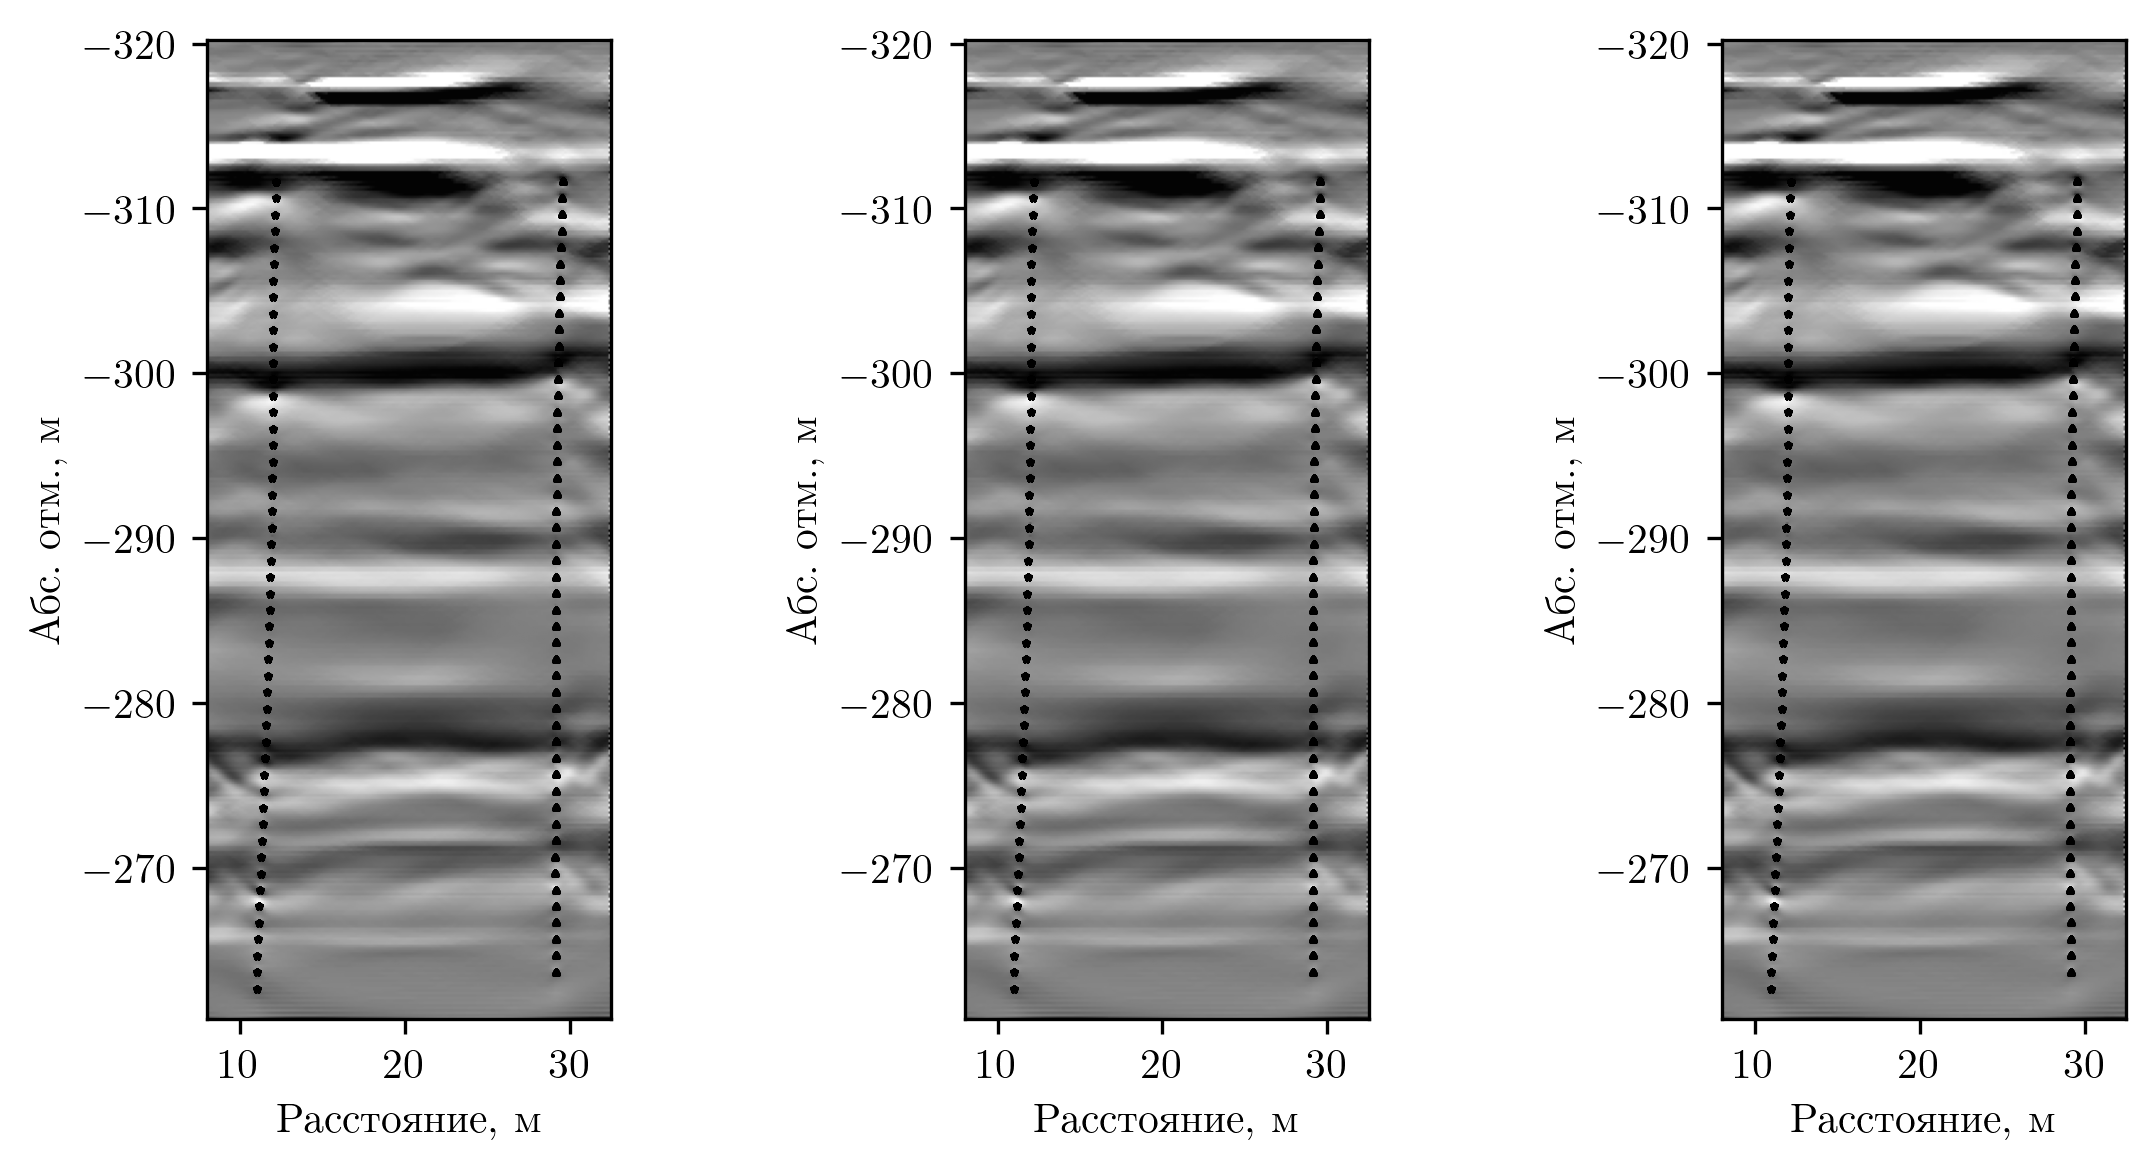

In [102]:
extent = [velmodel.x[0], velmodel.x[-1], velmodel.z[-1], velmodel.z[0]]
fig, axs = plt.subplots(1, 3, figsize=(8, 4), dpi=300)
glmax = max([np.quantile(grad_d1, 0.975), np.quantile(grad_u1, 0.975)])
for gr, ax in zip([grad_d1, grad_u1, imag1], axs):
    # h=ax.imshow(gr.T,
    #             vmin=-glmax, vmax=glmax,
    #             cmap='gray', extent=extent)
    # hh=ax.imshow(model.vp.data[NBL:-NBL, NBL:-NBL].T, cmap='viridis', vmin=0.5, vmax=5.5, alpha=0.3, extent=extent)
    hh=ax.imshow(np.diff(np.log(buff.T), axis=0), cmap='gray', alpha=0.99, vmin=-1e-1, vmax=1e-1, extent=extent)

    ax.scatter(dataset.x_coords, dataset.elevations, s=1, c='k', marker='*')
    ax.scatter(dataset.opposite_x, dataset.opposite_elev, s=1, c='k', marker='^')
    
    ax.set_xlabel("Расстояние, м")
    ax.set_ylabel("Абс. отм., м")

plt.tight_layout()
plt.show()

In [97]:
d_syn = np.load(f"./adjoint_snaps/recon_gather_{35}.npy")
print(d_syn.shape)

FileNotFoundError: [Errno 2] No such file or directory: './adjoint_snaps/recon_gather_35.npy'

In [80]:
# dataset._dt_r = model.critical_dt
d_obs = dataset[34][0]
print(d_obs.shape)

(49, 12366)


In [54]:
print(np.quantile(d_obs, 0.99))
print(np.quantile(d_syn, 0.99))
scale_factor = np.sqrt(np.sum(d_obs.ravel()**2))/np.sqrt(np.sum(d_syn.ravel()**2))
print(scale_factor)

0.0034843929446527707
0.0002573047
12.768464405397944


In [82]:
d_syn /= np.linalg.norm(d_syn, axis=0)
d_obs /= np.linalg.norm(d_obs, axis=1).reshape(-1, 1)

In [77]:
model, dataset, velmodel = setup_model_and_geometry(path_data=PATH_DATA_DPLUS)
dataset._dt_r = model.critical_dt
dataset._t_max_r = TMAX
dataset.resample_on()

Operator `initdamp` ran in 0.01 s


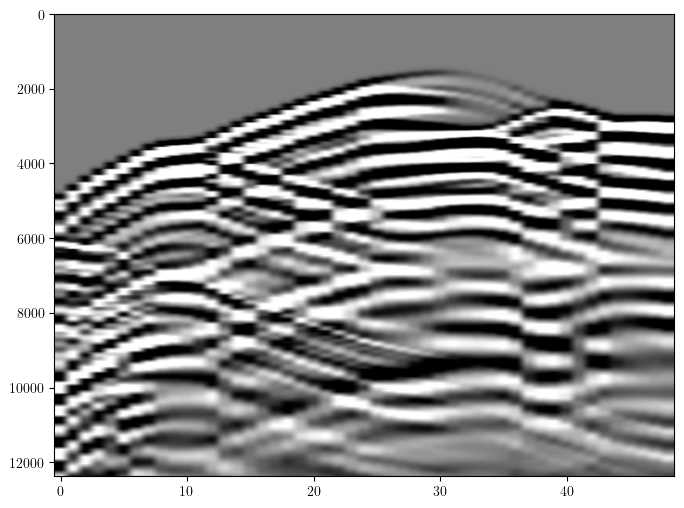

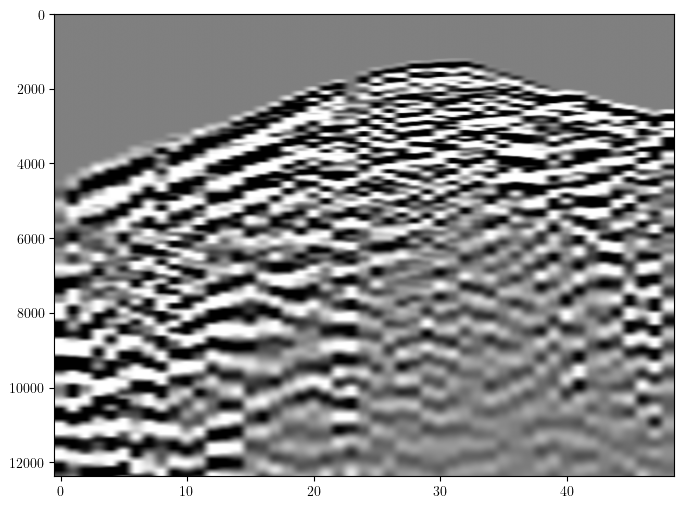

In [85]:
from matplotlib import pyplot as plt
qa = 0.01
plt.imshow(-d_syn, aspect='auto', vmin=-qa, vmax=qa, cmap='gray')
plt.show()
plt.imshow(d_obs.T, aspect='auto', vmin=-qa, vmax=qa, cmap='gray')
plt.show()